<h2 align="center"> Logistic Regression </h2>

### Task 2: Load the Data and Libraries
---

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.style.use("ggplot")
%matplotlib inline

In [10]:
from pylab import rcParams
rcParams['figure.figsize'] = 12, 8

In [11]:
df = pd.read_csv('DMV_Written_Tests.csv')

In [12]:
df.head()

,DMV_Test_1,DMV_Test_2,Results
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


### Task 3: Visualize the Data
---

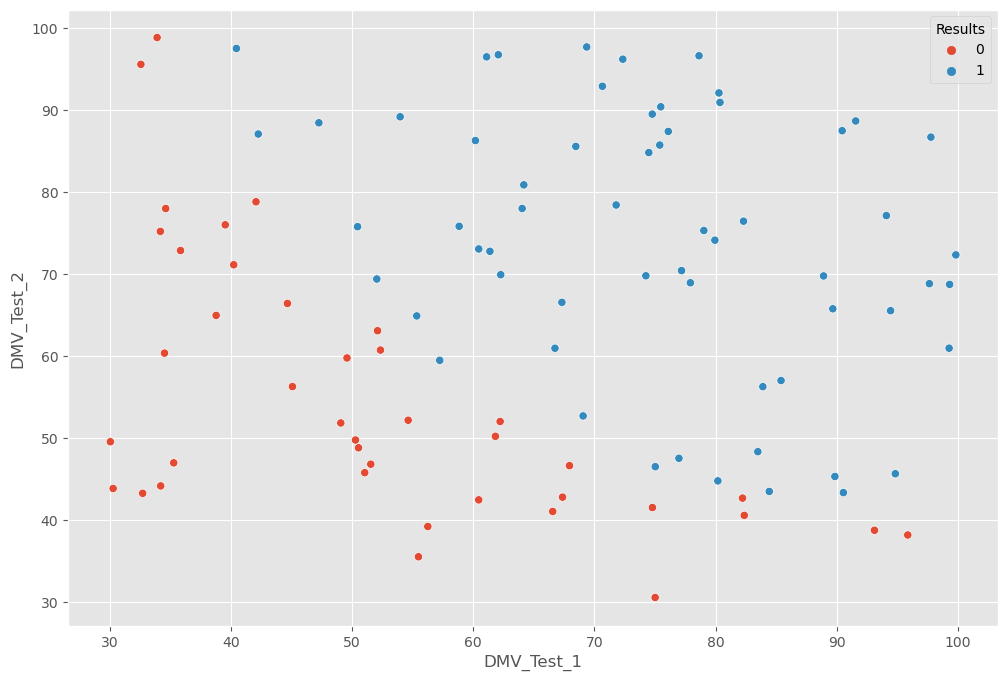

In [13]:
sns.scatterplot(x='DMV_Test_1', y='DMV_Test_2', hue='Results', data=df)
plt.show()

### Task 4: Define the Logistic Sigmoid Function $\sigma(z)$
---

$$ \sigma(z) = \frac{1}{1+e^{-z}}$$

In [14]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [15]:
sigmoid(0)

0.5

### Task 5: Compute the Cost Function $J(\theta)$ and Gradient
---

The objective of logistic regression is to minimize the cost function

$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} [ y^{(i)}log(h_{\theta}(x^{(i)})) + (1 - y^{(i)})log(1 - (h_{\theta}(x^{(i)}))]$$

where the gradient of the cost function is given by

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} (h_{\theta}(x^{(i)}) - y^{(i)})x_j^{(i)}$$

In [19]:
def compute_cost(theta, X, y):
    m = len(y)

    h = sigmoid(np.dot(X, theta))

    cost = (-1/m) * np.sum(
        y * np.log(h) + (1 - y) * np.log(1 - h)
    )

    gradient = (1/m) * np.dot(X.T, (h - y))

    return cost, gradient

X = df[['DMV_Test_1', 'DMV_Test_2']].values
y = df['Results'].values

### Task 6: Cost and Gradient at Initialization
---

In [20]:
theta = np.zeros(X.shape[1])
cost, grad = compute_cost(theta, X, y)

print("Cost:", cost)
print("Gradient:", grad)

Cost: 0.6931471805599453
Gradient: [-12.00921659 -11.26284221]


In [21]:
cost

0.6931471805599453

### Task 7: Gradient Descent
---

Minimize the cost function $J(\theta)$ by updating the below equation and repeat until convergence
$\theta_j := \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j}$ (simultaneously update $\theta_j$ for all $j$)

In [22]:
def gradient_descent(theta, X, y, alpha, iterations):
    cost_history = []

    for i in range(iterations):
        cost, grad = compute_cost(theta, X, y)
        theta = theta - alpha * grad
        cost_history.append(cost)

    return theta, cost_history

In [23]:
alpha = 0.001
iterations = 1000

theta = np.zeros(X.shape[1])

theta, cost_history = gradient_descent(
    theta, X, y, alpha, iterations
)

In [24]:
theta

array([0.01042527, 0.00045203])

### Task 8: Plotting the Convergence of $J(\theta)$
---

Plot $J(\theta)$ against the number of iterations of gradient descent:

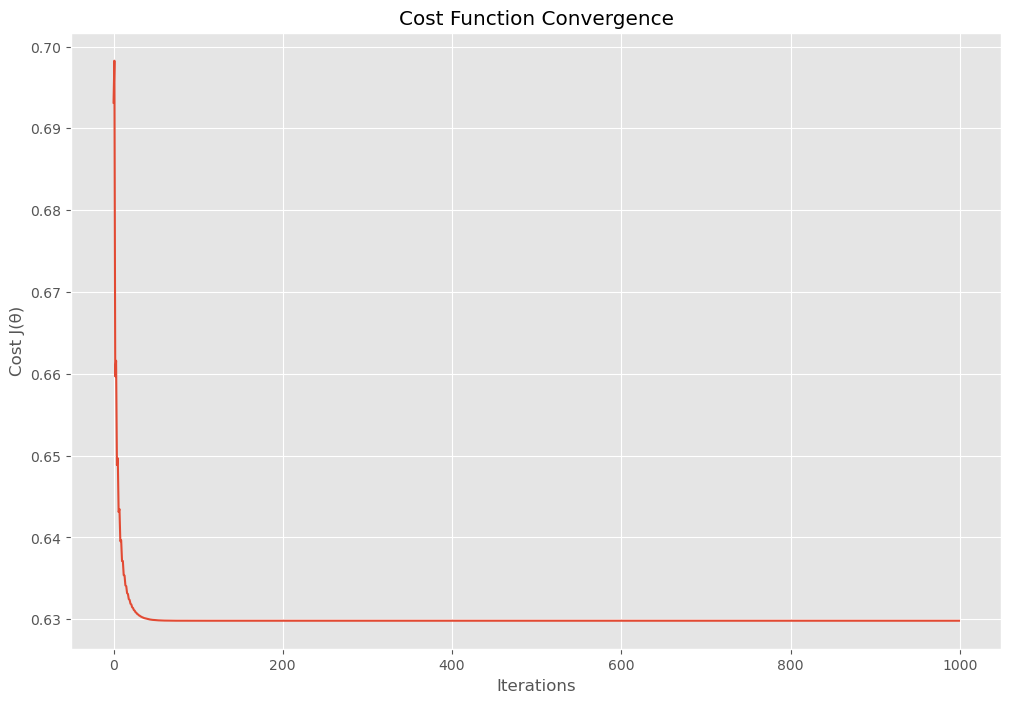

In [25]:
plt.plot(cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost J(θ)')
plt.title('Cost Function Convergence')
plt.show()

In [26]:
cost_history[-1]

0.6298158516905145

### Task 9: Plotting the decision boundary
---

$h_\theta(x) = \sigma(z)$, where $\sigma$ is the logistic sigmoid function and $z = \theta^Tx$

When $h_\theta(x) \geq 0.5$ the model predicts class "1":

$\implies \sigma(\theta^Tx) \geq 0.5$

$\implies \theta^Tx \geq 0$ predict class "1" 

Hence, $\theta_1 + \theta_2x_2 + \theta_3x_3 = 0$ is the equation for the decision boundary, giving us 

$ x_3 = \frac{-(\theta_1+\theta_2x_2)}{\theta_3}$

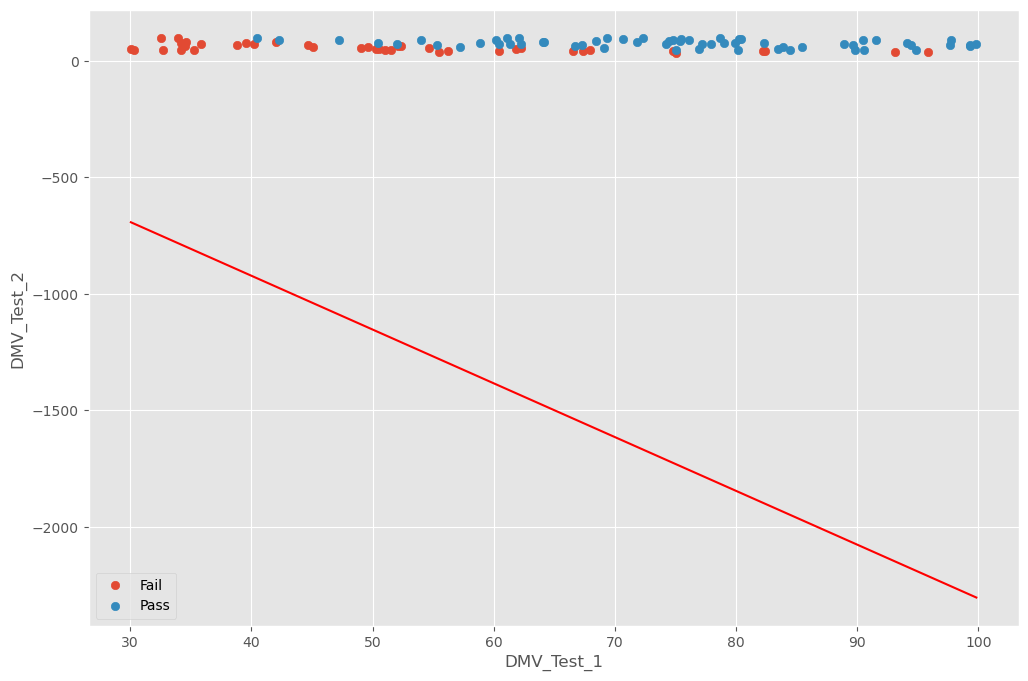

In [27]:
x1 = np.array([X[:,0].min(), X[:,0].max()])
x2 = -(theta[0] * x1) / theta[1]

plt.scatter(X[y==0][:,0], X[y==0][:,1], label='Fail')
plt.scatter(X[y==1][:,0], X[y==1][:,1], label='Pass')

plt.plot(x1, x2, 'r')
plt.xlabel('DMV_Test_1')
plt.ylabel('DMV_Test_2')
plt.legend()
plt.show()

In [28]:
theta

array([0.01042527, 0.00045203])

### Task 10: Predictions using the optimized $\theta$ values
---

$h_\theta(x) = x\theta$

In [29]:
def predict(theta, X):
    return sigmoid(np.dot(X, theta))

In [30]:
predictions = predict(theta, X)
predictions[:10]

array([0.5977816 , 0.5831186 , 0.60028977, 0.66070411, 0.70224161,
       0.62139224, 0.66389026, 0.69065788, 0.69696074, 0.71093163])

In [31]:
(predictions >= 0.5).astype(int)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [32]:
accuracy = np.mean((predictions >= 0.5) == y) * 100
print("Accuracy:", accuracy)

Accuracy: 60.0
